## Graphing the "phenotest" light habituation done prior to R stats Jacobson-style conditioning

We exposed troupes of 6 worms each to 20 trials of LO per day, then assessed. The high-responders got grouped into high-responders, less high into low-responders, no-responders not used.

## 1. Imports, pathways, set-up

In [5]:
# ==============================================================================
# BLOCK 1: IMPORTS, CONFIGURATION, AND PATHWAYS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# --- FILE PATHS ---
CSV_FILEPATH = "PhenoTest_EXPORT.csv"
SAVE_PATH = "."

# --- PLOTTING CONFIGURATION DICTIONARY ---
PLOT_CONFIG = {
    'General': {
        'figsize_line': (8, 6),
        'figsize_raster': (10, 8),
        'figsize_bar': (12, 6),     # Wider figure to fit all the bars cleanly
        'dpi': 150,
        'save_dpi': 300,
        'ylim_line': (-0.05, 1.05)
    },
    'Troupe_Means': {
        'linewidth': 2.5,
        'markersize': 8,
        'marker': 'o',
        'capsize': 5,
        'alpha': 1.0,
        'cmap': 'tab10' 
    },
    'Spaghetti': {
        'worm_color': '#7f8c8d',  
        'worm_alpha': 0.65,
        'worm_linewidth': 2.0,
        'worm_markersize': 4,
        'worm_marker': 'o',
        'plot_grand_mean': True,  
        'gm_color': 'red',
        'gm_linewidth': 3.0,
        'gm_markersize': 9,
        'gm_marker': 'D',
        'gm_capsize': 5
    },
    'Raster': {
        'marker_shape': 's',       
        'marker_size': 85,         
        'filled_face': 'black',    
        'filled_edge': 'black',    
        'unfilled_face': 'none',   
        'unfilled_edge': 'black',  
        'gap_color': 'red',        
        'gap_shade': 'gray',       
        'gap_alpha': 0.15
    },
    'Sorted_Bar': {
        'bar_color': '#ffe93d',
        'bar_edgecolor': 'gray',
        'bar_alpha': 0.7,
        'day1_color': '#edd200',   # 
        'day1_marker': 'o',
        'day2_color': '#edd200',   # 
        'day2_marker': '^',        # Triangle to easily distinguish from Day 1
        'scatter_size': 10,
        'scatter_zorder': 3        # Ensures points render on top of the bars
    }
}

plt.rcParams['figure.dpi'] = PLOT_CONFIG['General']['dpi']
plt.rcParams['savefig.dpi'] = PLOT_CONFIG['General']['save_dpi']

## 2. Define csv analysis and graphing functions

In [6]:
# ==============================================================================
# BLOCK 2A: CSV PARSING AND PREPROCESSING
# ==============================================================================
def load_and_preprocess_data(filepath):
    """Parses raw hand-scored CSV into long format for graphing."""
    df = pd.read_csv(filepath)
    df = df.dropna(subset=['Trial']).copy()
    
    # Forward-fill missing Run, Troupe, and Day data
    df[['Run', 'Troupe', 'Day']] = df[['Run', 'Troupe', 'Day']].ffill()
    
    worm_cols = ['W1', 'W2', 'W3', 'W4', 'W5', 'W6']
    df_long = pd.melt(df, 
                      id_vars=['Run', 'Troupe', 'Day', 'Trial'], 
                      value_vars=worm_cols,
                      var_name='Worm_ID', 
                      value_name='Score')
    
    # Coerce NA, Q, etc. to NaN, and then immediately fill those NaNs with 0
    df_long['Score'] = pd.to_numeric(df_long['Score'], errors='coerce').fillna(0)
    
    # Ensure Day and Trial are numeric
    df_long['Day'] = pd.to_numeric(df_long['Day'], errors='coerce')
    df_long['Trial'] = pd.to_numeric(df_long['Trial'], errors='coerce')
    
    df_long['Unique_Worm'] = df_long['Troupe'] + '_' + df_long['Worm_ID']
    
    # Calculate Absolute Trial for Raster (Gap between days)
    def calc_abs_trial(row):
        if pd.isna(row['Day']) or pd.isna(row['Trial']): return np.nan
        if row['Day'] == 1: return row['Trial']
        return row['Trial'] + (21 * (row['Day'] - 1))
            
    df_long['Absolute_Trial'] = df_long.apply(calc_abs_trial, axis=1)
    
    return df_long

# ==============================================================================
# BLOCK 2B: GRAPH 1 - TROUPE MEANS
# ==============================================================================
def plot_troupe_means(df_long, save=False):
    cfg = PLOT_CONFIG['Troupe_Means']
    fig, ax = plt.subplots(figsize=PLOT_CONFIG['General']['figsize_line'])
    
    # Drop NaNs before doing math
    df_clean = df_long.dropna(subset=['Score'])
    troupe_means = df_clean.groupby(['Troupe', 'Day'])['Score'].agg(['mean', 'sem']).reset_index()
    troupes = troupe_means['Troupe'].unique()
    
    colors = plt.cm.get_cmap(cfg['cmap'])(np.linspace(0, 1, len(troupes))) 
    
    for idx, troupe in enumerate(troupes):
        subset = troupe_means[troupe_means['Troupe'] == troupe]
        ax.errorbar(subset['Day'], subset['mean'], yerr=subset['sem'], 
                    marker=cfg['marker'], markersize=cfg['markersize'], 
                    linewidth=cfg['linewidth'], capsize=cfg['capsize'],
                    alpha=cfg['alpha'], color=colors[idx], label=troupe)
        
    days = sorted(df_clean['Day'].unique())
    ax.set_xticks(days)
    ax.set_xticklabels([f'Day {int(d)}' for d in days])
    ax.set_ylabel('Mean Response Rate', fontsize=12, fontweight='bold')
    ax.set_xlabel('Session', fontsize=12, fontweight='bold')
    ax.set_title('Mean Response Rate by Troupe', fontsize=14)
    ax.set_ylim(PLOT_CONFIG['General']['ylim_line'])
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.legend(title="Troupes", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    if save: plt.savefig(os.path.join(SAVE_PATH, "Troupe_Means.svg"))
    plt.show()

# ==============================================================================
# BLOCK 2C: GRAPH 2 - WORM SPAGHETTI PLOT
# ==============================================================================
def plot_worm_spaghetti(df_long, save=False):
    cfg = PLOT_CONFIG['Spaghetti']
    fig, ax = plt.subplots(figsize=PLOT_CONFIG['General']['figsize_line'])
    
    df_clean = df_long.dropna(subset=['Score'])
    worm_means = df_clean.groupby(['Unique_Worm', 'Day'])['Score'].mean().reset_index()
    days = sorted(df_clean['Day'].unique())
    
    # Individual worms
    for unique_worm in worm_means['Unique_Worm'].unique():
        subset = worm_means[worm_means['Unique_Worm'] == unique_worm]
        ax.plot(subset['Day'], subset['Score'], marker=cfg['worm_marker'], 
                markersize=cfg['worm_markersize'], color=cfg['worm_color'], 
                alpha=cfg['worm_alpha'], linewidth=cfg['worm_linewidth'])
        
    # Grand Mean
    if cfg['plot_grand_mean']:
        grand_mean = df_clean.groupby('Day')['Score'].agg(['mean', 'sem']).reset_index()
        ax.errorbar(grand_mean['Day'], grand_mean['mean'], yerr=grand_mean['sem'],
                    marker=cfg['gm_marker'], markersize=cfg['gm_markersize'], 
                    color=cfg['gm_color'], linewidth=cfg['gm_linewidth'], 
                    capsize=cfg['gm_capsize'], label='Mean')
        ax.legend(loc='best')

    ax.set_xticks(days)
    ax.set_xticklabels([f'Day {int(d)}' for d in days])
    ax.set_ylabel('Mean Response Rate', fontsize=12, fontweight='bold')
    ax.set_xlabel('Session', fontsize=12, fontweight='bold')
    ax.set_title('Individual Worm Trajectories', fontsize=14)
    ax.set_ylim(PLOT_CONFIG['General']['ylim_line'])
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    if save: plt.savefig(os.path.join(SAVE_PATH, "Worm_Spaghetti.svg"))
    plt.show()

# ==============================================================================
# BLOCK 2D: GRAPH 3 - TRIAL-BY-TRIAL RASTER PLOT
# ==============================================================================
def plot_worm_raster(df_long, save=False):
    cfg = PLOT_CONFIG['Raster']
    fig, ax = plt.subplots(figsize=PLOT_CONFIG['General']['figsize_raster'])
    
    # Drop rows where Absolute_Trial couldn't be calculated
    df_clean = df_long.dropna(subset=['Absolute_Trial']).copy()
    
    # SORTING LOGIC: 
    # Calculate total numeric sum per worm. (NAs and Qs are already 0 now)
    # We sort ascending=True so the lowest scores are at index 0 (bottom of Y-axis)
    worm_totals = df_clean.groupby('Unique_Worm')['Score'].sum().sort_values(ascending=True)
    sorted_worms = worm_totals.index.tolist()
    
    # Map each worm to a strict integer coordinate on the Y-axis
    y_mapping = {worm: i for i, worm in enumerate(sorted_worms)}
    df_clean['Y_Coord'] = df_clean['Unique_Worm'].map(y_mapping)
    
    # Split Hits (1s) and Misses (0s)
    df_hits = df_clean[df_clean['Score'] == 1]
    df_misses = df_clean[df_clean['Score'] == 0]
    
    # Plot Misses (Unfilled squares - this now includes former NAs and Qs)
    ax.scatter(df_misses['Absolute_Trial'], df_misses['Y_Coord'], 
               marker=cfg['marker_shape'], s=cfg['marker_size'],
               facecolors=cfg['unfilled_face'], edgecolors=cfg['unfilled_edge'],
               label='No Response / NA (0)')
               
    # Plot Hits (Filled squares)
    ax.scatter(df_hits['Absolute_Trial'], df_hits['Y_Coord'], 
               marker=cfg['marker_shape'], s=cfg['marker_size'],
               facecolors=cfg['filled_face'], edgecolors=cfg['filled_edge'],
               label='Response (1)')
    
    # Visual Break for Day 1 vs Day 2
    ax.axvline(x=21, color=cfg['gap_color'], linestyle='--', linewidth=2, label='Day Break')
    ax.axvspan(20.5, 21.5, color=cfg['gap_shade'], alpha=cfg['gap_alpha']) 

    # Format X-axis
    ax.set_xlim(0, 43)
    ax.set_xticks([]) # Removes X ticks and numerical labels
    
    # Format Y-axis (Remove individual labels)
    ax.set_yticks([]) 
    ax.set_ylabel(f'Individual Worms (N={len(sorted_worms)})\n↓ Lowest Responders       Highest Responders ↑', 
                  fontsize=12, fontweight='bold', labelpad=15)
    
    # Main Axis Titles
    ax.set_xlabel('Trial Number (Day 1 -> Day 2)', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_title('Raster Plot of Responses (Sorted by Total Score)', fontsize=14)
    
    # Place legend outside plot
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    if save: plt.savefig(os.path.join(SAVE_PATH, "Worm_Raster.svg"))
    plt.show()

# ==============================================================================
# BLOCK 2E: GRAPH 4 - SORTED BAR CHART OF WORM MEANS
# ==============================================================================
def plot_sorted_bar(df_long, save=False):
    cfg = PLOT_CONFIG['Sorted_Bar']
    fig, ax = plt.subplots(figsize=PLOT_CONFIG['General']['figsize_bar'])
    
    # 1. Calculate overall mean per worm to determine bar heights and sorting order
    overall_means = df_long.groupby('Unique_Worm')['Score'].mean().reset_index()
    
    # Sort descending: largest mean on the far left
    overall_means = overall_means.sort_values(by='Score', ascending=False).reset_index(drop=True)
    sorted_worms = overall_means['Unique_Worm'].tolist()
    
    # Map each worm to an X-coordinate (0, 1, 2, ..., N)
    worm_to_x = {worm: i for i, worm in enumerate(sorted_worms)}
    overall_means['X_Coord'] = overall_means['Unique_Worm'].map(worm_to_x)
    
    # 2. Calculate Day 1 and Day 2 means for the scatter points
    daily_means = df_long.groupby(['Unique_Worm', 'Day'])['Score'].mean().reset_index()
    daily_means['X_Coord'] = daily_means['Unique_Worm'].map(worm_to_x)
    
    day1_data = daily_means[daily_means['Day'] == 1]
    day2_data = daily_means[daily_means['Day'] == 2]
    
    # 3. Plotting
    # Plot the background bars (Overall Mean)
    ax.bar(overall_means['X_Coord'], overall_means['Score'], 
           color=cfg['bar_color'], edgecolor=cfg['bar_edgecolor'], 
           alpha=cfg['bar_alpha'], label='Overall Mean')
    
    # Plot Day 1 points
    ax.scatter(day1_data['X_Coord'], day1_data['Score'], 
               color=cfg['day1_color'], marker=cfg['day1_marker'], 
               s=cfg['scatter_size'], zorder=cfg['scatter_zorder'], label='Day 1 Mean')
               
    # Plot Day 2 points
    ax.scatter(day2_data['X_Coord'], day2_data['Score'], 
               color=cfg['day2_color'], marker=cfg['day2_marker'], 
               s=cfg['scatter_size'], zorder=cfg['scatter_zorder'], label='Day 2 Mean')

    # 4. Formatting
    ax.set_ylim(PLOT_CONFIG['General']['ylim_line'])
    ax.set_xlim(-1, len(sorted_worms))
    
    # Remove X-ticks and labels
    ax.set_xticks([])
    
    ax.set_xlabel(f'Individual Worms (N={len(sorted_worms)})', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_ylabel('Mean Response Rate (0 to 1)', fontsize=12, fontweight='bold')
    ax.set_title('Worm Response Rates (Sorted by Overall Mean)', fontsize=14)
    
    # Grid lines only on the Y axis for readability
    ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
    
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    if save: plt.savefig(os.path.join(SAVE_PATH, "Worm_Sorted_Bar.svg"))
    plt.show()

## 3. Call and run graphing functions

Data successfully parsed!
Total valid trials processed: 1440
Unique Troupes found: ['Ph_1' 'Ph_2' 'Ph_3' 'Ph_4' 'Ph_5' 'Ph_6']
----------------------------------------


/var/folders/9y/7nb_p7wj29v415z0wjc298yr0000gn/T/ipykernel_88621/1403829426.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(cfg['cmap'])(np.linspace(0, 1, len(troupes)))


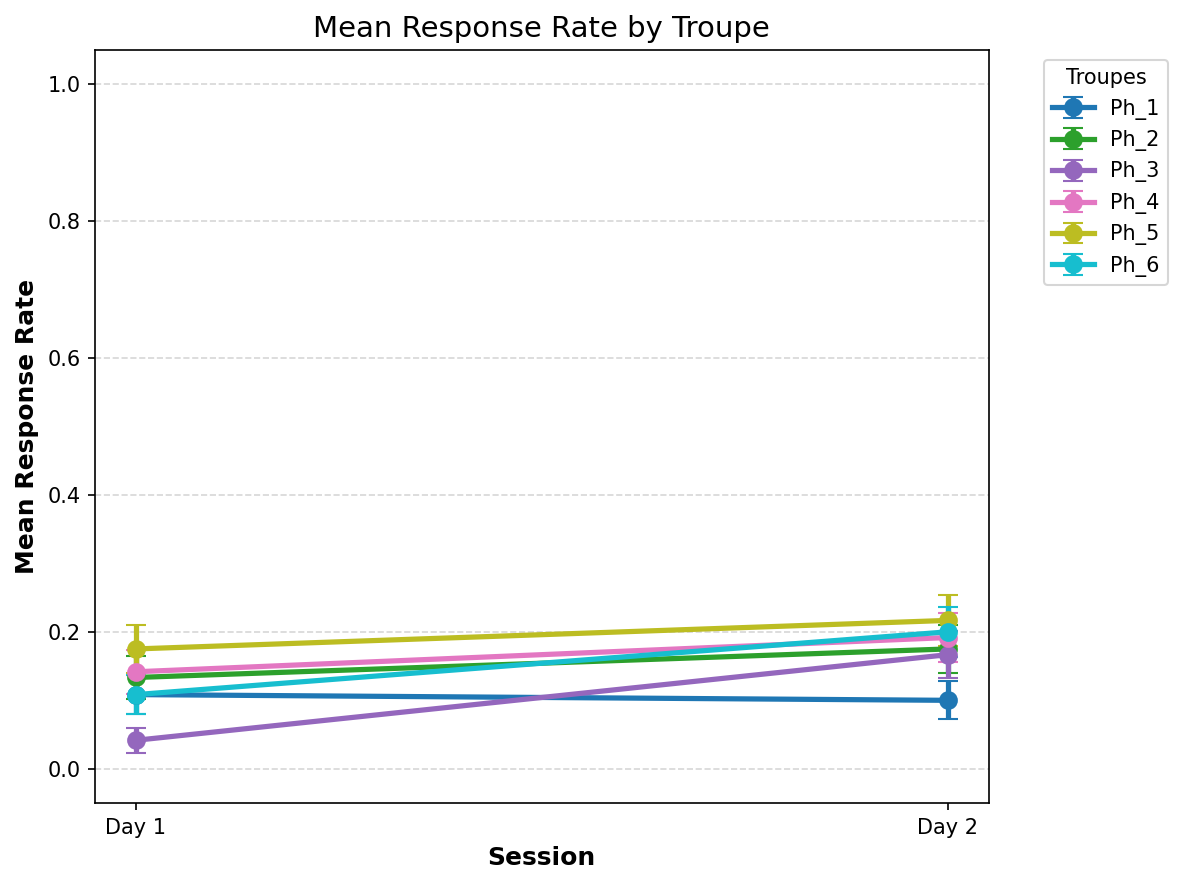

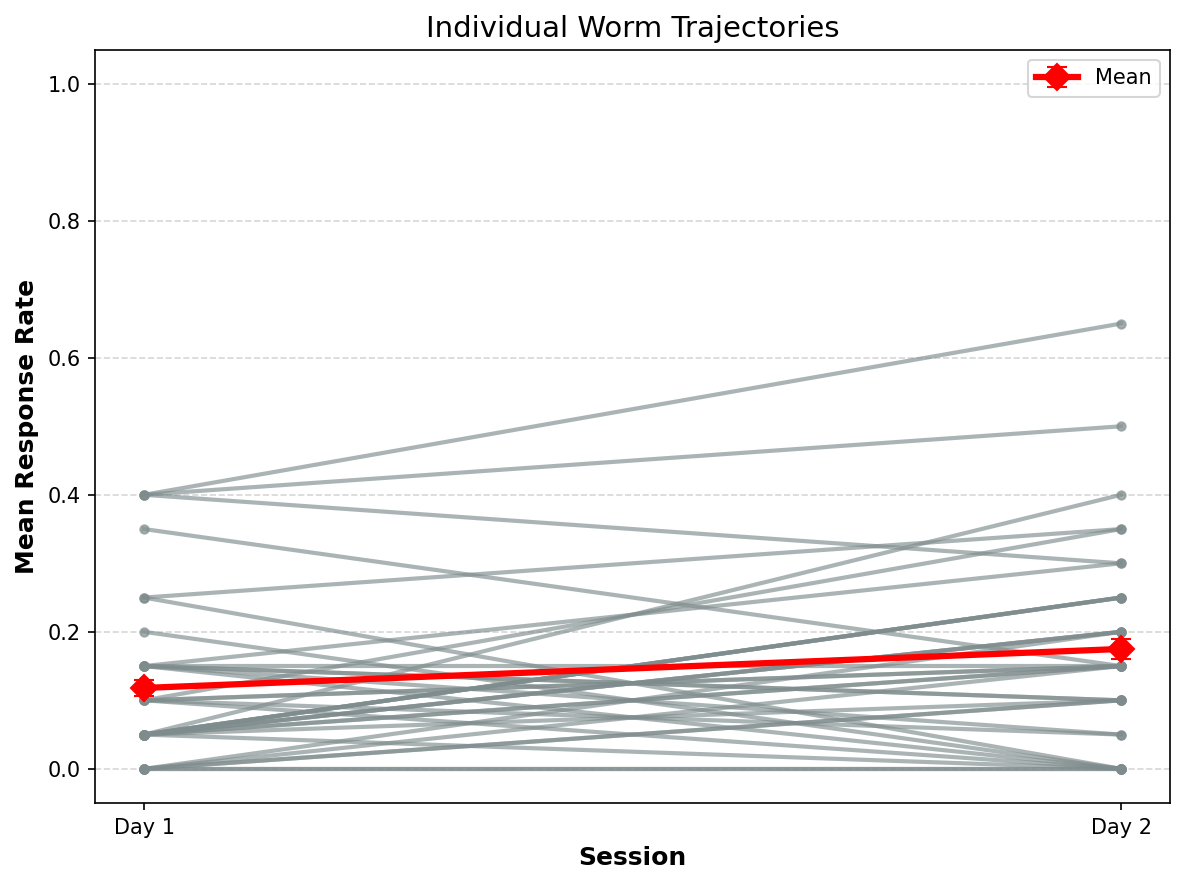

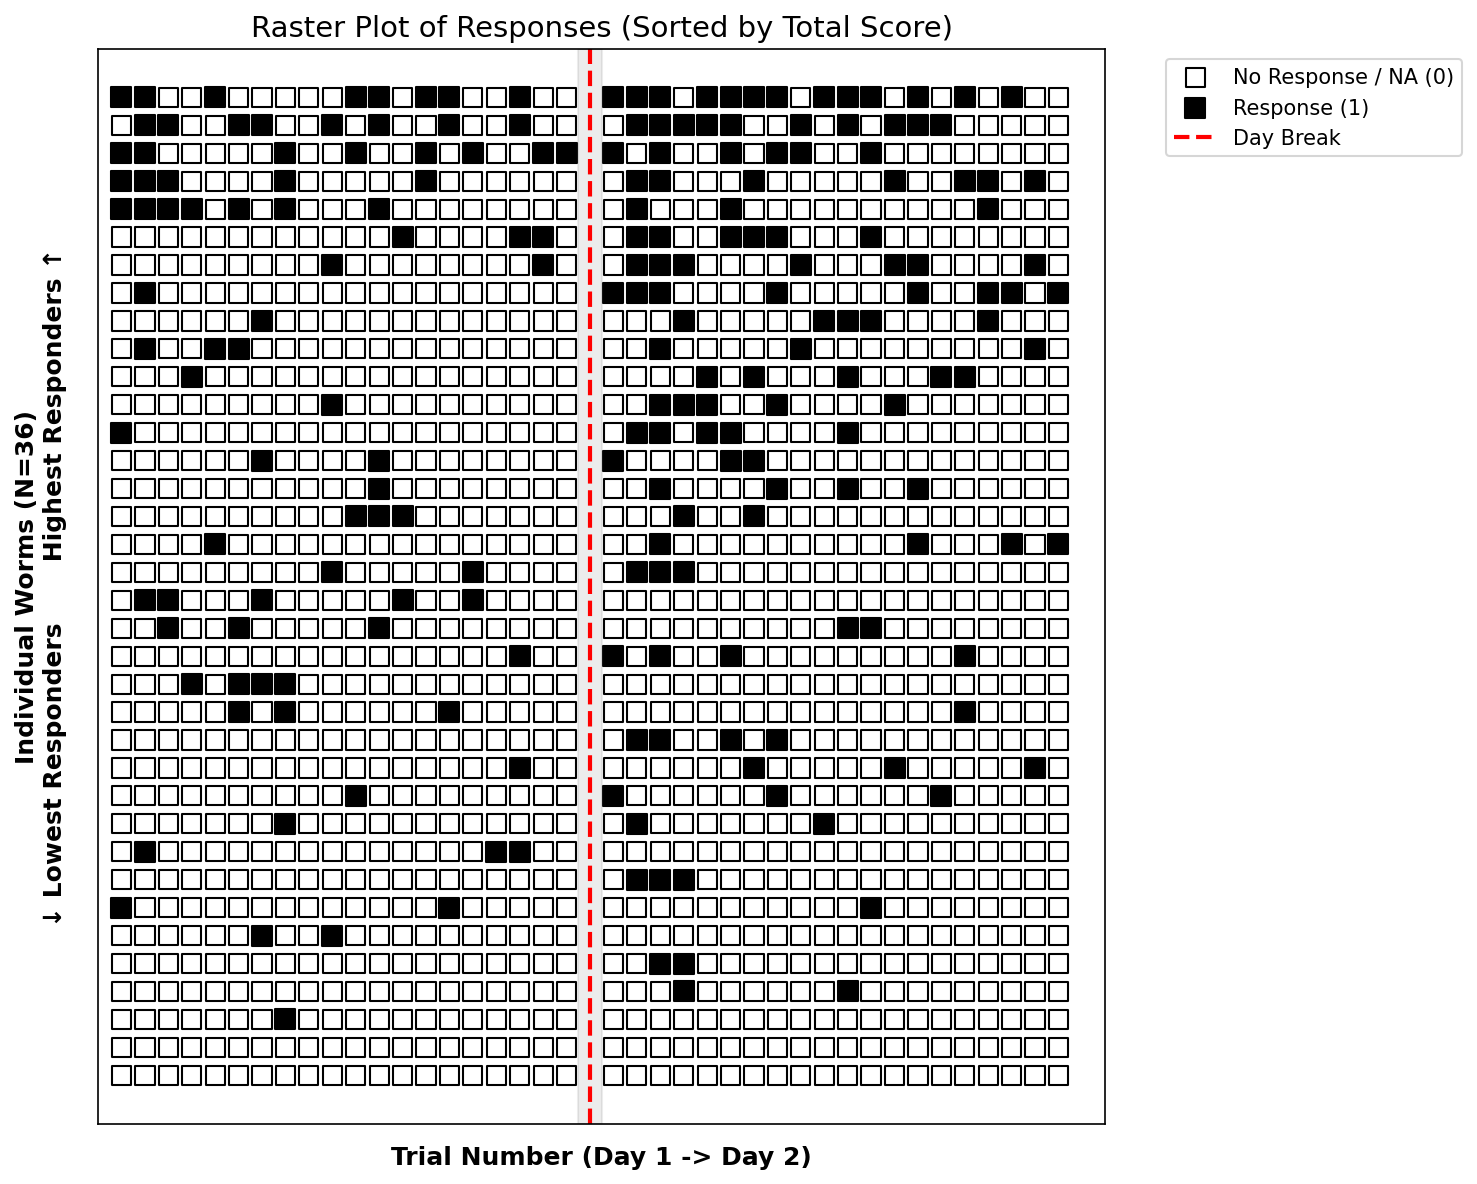

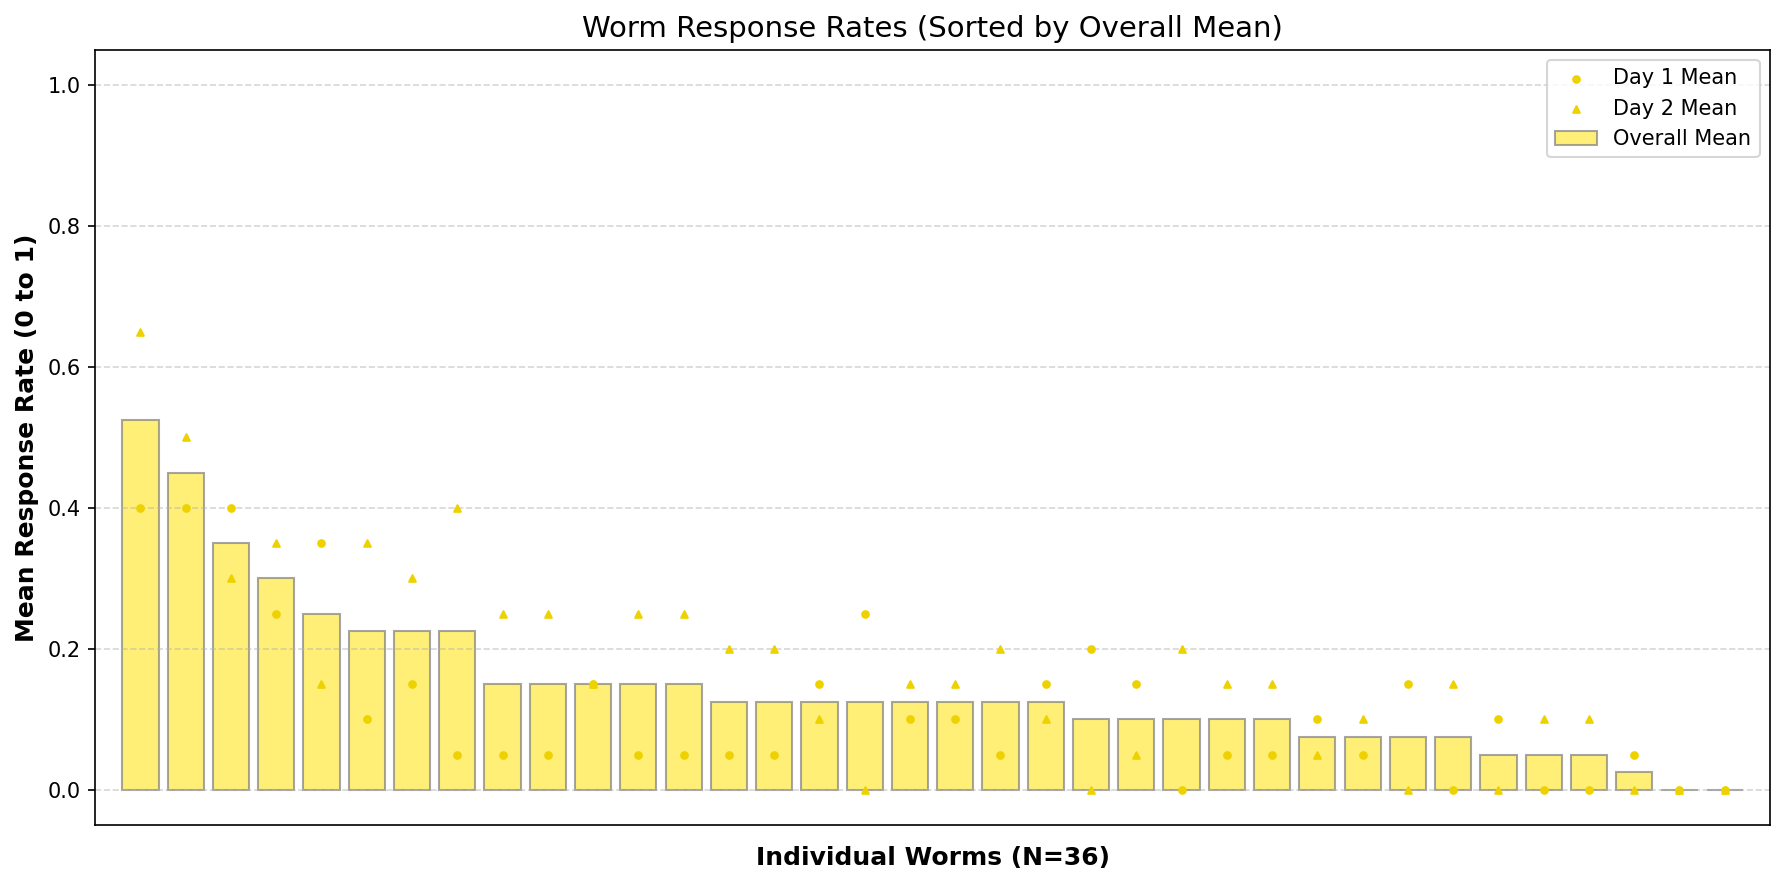

In [7]:
# ==============================================================================
# BLOCK 3: EXECUTION
# ==============================================================================

# 1. Parse Data
# Note: Ensure you updated CSV_FILEPATH in Block 1
df_processed = load_and_preprocess_data(CSV_FILEPATH)

print("Data successfully parsed!")
print(f"Total valid trials processed: {len(df_processed.dropna(subset=['Score']))}")
print(f"Unique Troupes found: {df_processed['Troupe'].unique()}")
print("-" * 40)

# 2. Generate Graphs
# (Change save=True to save out SVGs)

plot_troupe_means(df_processed, save=False)

plot_worm_spaghetti(df_processed, save=True)

plot_worm_raster(df_processed, save=False)

plot_sorted_bar(df_processed, save=False)

## Testing

In [8]:
# ==============================================================================
# BLOCK 2F: GRAPH 5 - TOP 33% SPAGHETTI PLOT
# ==============================================================================
def plot_top_responders_spaghetti(df_long, top_fraction=0.33, save=False):
    cfg = PLOT_CONFIG['Spaghetti']
    fig, ax = plt.subplots(figsize=PLOT_CONFIG['General']['figsize_line'])
    
    df_clean = df_long.dropna(subset=['Score'])
    
    # 1. Identify the top 33% of responders
    # Calculate overall mean per worm and sort descending
    worm_overall = df_clean.groupby('Unique_Worm')['Score'].mean().sort_values(ascending=False)
    
    # Calculate how many worms make up the requested fraction (e.g., 33%)
    n_top = max(1, int(len(worm_overall) * top_fraction))
    top_worms = worm_overall.head(n_top).index.tolist()
    
    # 2. Filter the dataframe to only include these top worms
    df_top = df_clean[df_clean['Unique_Worm'].isin(top_worms)]
    
    # Calculate daily means for this specific subset
    worm_means = df_top.groupby(['Unique_Worm', 'Day'])['Score'].mean().reset_index()
    days = sorted(df_top['Day'].unique())
    
    # 3. Plot Individual Top Worms
    for unique_worm in top_worms:
        subset = worm_means[worm_means['Unique_Worm'] == unique_worm]
        ax.plot(subset['Day'], subset['Score'], marker=cfg['worm_marker'], 
                markersize=cfg['worm_markersize'], color=cfg['worm_color'], 
                alpha=cfg['worm_alpha'], linewidth=cfg['worm_linewidth'])
        
    # 4. Plot Grand Mean of the Subset
    if cfg['plot_grand_mean']:
        grand_mean = df_top.groupby('Day')['Score'].agg(['mean', 'sem']).reset_index()
        ax.errorbar(grand_mean['Day'], grand_mean['mean'], yerr=grand_mean['sem'],
                    marker=cfg['gm_marker'], markersize=cfg['gm_markersize'], 
                    color=cfg['gm_color'], linewidth=cfg['gm_linewidth'], 
                    capsize=cfg['gm_capsize'], label=f'Top {n_top} Grand Mean ± SEM')
        ax.legend(loc='best')

    # 5. Formatting
    ax.set_xticks(days)
    ax.set_xticklabels([f'Day {int(d)}' for d in days])
    ax.set_ylabel('Mean Response Rate', fontsize=12, fontweight='bold')
    ax.set_xlabel('Session', fontsize=12, fontweight='bold')
    
    # Update title to indicate it is a filtered subset
    percent_label = int(top_fraction * 100)
    ax.set_title(f'Worm Trajectories: Top {percent_label}% Responders (N={n_top})', fontsize=14)
    
    ax.set_ylim(PLOT_CONFIG['General']['ylim_line'])
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    if save: plt.savefig(os.path.join(SAVE_PATH, f"Worm_Spaghetti_Top{percent_label}.svg"))
    plt.show()

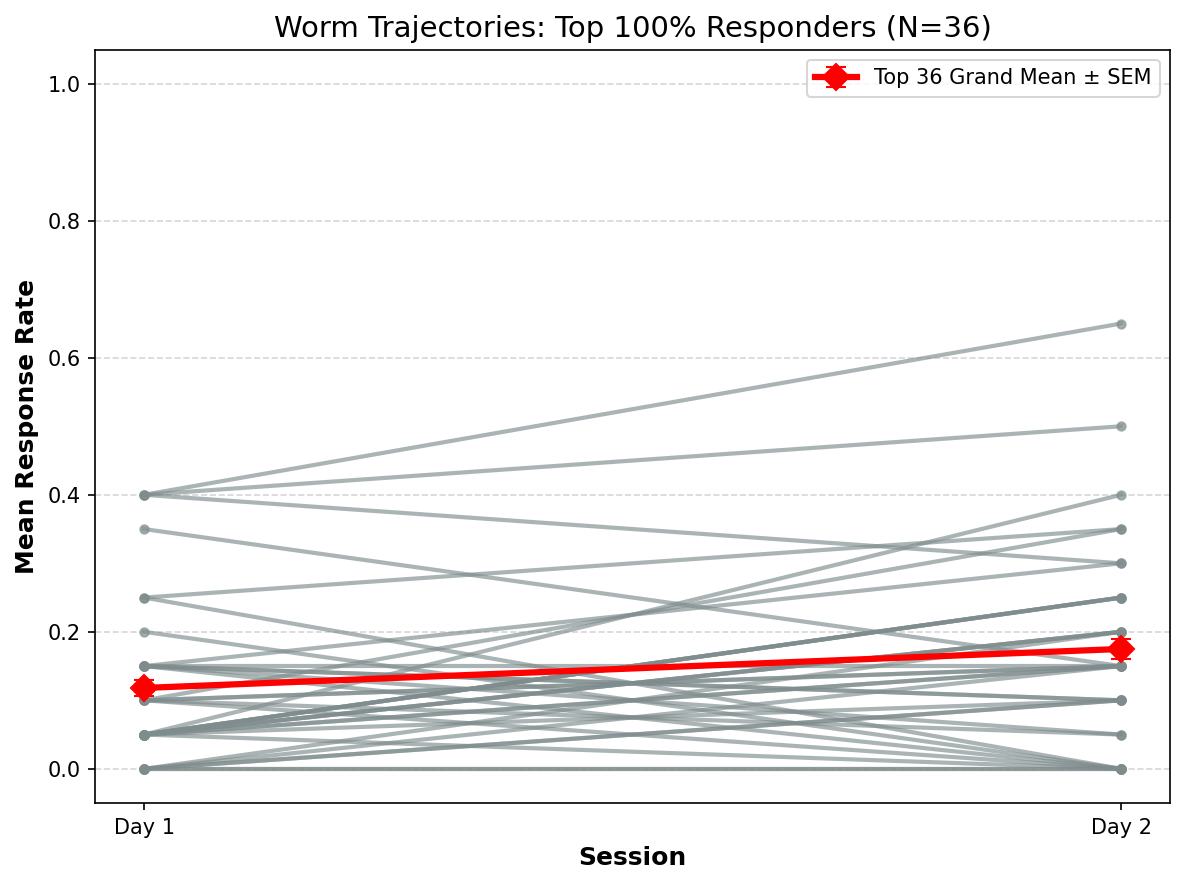

In [9]:
# --> GRAPH 5: Top 33% Spaghetti Plot <--
# You can easily change top_fraction to 0.5 for top 50%, 0.1 for top 10%, etc.
plot_top_responders_spaghetti(df_processed, top_fraction=1, save=False)

## Statistics: Is there a significant increase in mean response rate over time?

In [10]:
import numpy as np
from scipy import stats as sp_stats
import warnings

sep = "=" * 65

# ══════════════════════════════════════════════════════════════════════
#  1. DAY-LEVEL: Paired comparison (Day 1 vs Day 2 per-worm means)
# ══════════════════════════════════════════════════════════════════════
print(sep)
print("  1. DAY-LEVEL ANALYSIS: Day 1 vs Day 2 per-worm mean response")
print(sep)

df_clean = df_processed.dropna(subset=["Score"])
worm_day_means = df_clean.groupby(["Unique_Worm", "Day"])["Score"].mean().reset_index()
pivoted = worm_day_means.pivot(index="Unique_Worm", columns="Day", values="Score").dropna()

day1_vals = pivoted[1].values
day2_vals = pivoted[2].values
n_worms = len(day1_vals)
diffs = day2_vals - day1_vals

print(f"  N worms: {n_worms}")
print(f"  Day 1 mean: {np.mean(day1_vals):.4f} +/- {np.std(day1_vals, ddof=1)/np.sqrt(n_worms):.4f} SEM")
print(f"  Day 2 mean: {np.mean(day2_vals):.4f} +/- {np.std(day2_vals, ddof=1)/np.sqrt(n_worms):.4f} SEM")
print(f"  Mean difference (Day2 - Day1): {np.mean(diffs):+.4f} +/- {np.std(diffs, ddof=1)/np.sqrt(n_worms):.4f} SEM")

# Paired t-test
t_stat, p_two = sp_stats.ttest_rel(day2_vals, day1_vals)
p_one_up = p_two / 2 if t_stat > 0 else 1 - p_two / 2

# Cohen's d (paired)
d_z = np.mean(diffs) / np.std(diffs, ddof=1)

print(f"\n  Paired t-test: t({n_worms-1}) = {t_stat:+.3f}, p(two-sided) = {p_two:.4f}, p(one-sided increase) = {p_one_up:.4f}")
print(f"  Cohen's d_z (paired): {d_z:+.3f}")

# Wilcoxon signed-rank (non-parametric paired test)
# Only works if there are nonzero differences
nonzero_diffs = diffs[diffs != 0]
if len(nonzero_diffs) >= 1:
    try:
        w_stat, p_wilc = sp_stats.wilcoxon(day2_vals, day1_vals, alternative="greater")
        print(f"  Wilcoxon signed-rank (one-sided increase): W = {w_stat:.1f}, p = {p_wilc:.4f}")
    except Exception as e:
        print(f"  Wilcoxon signed-rank: could not compute ({e})")
else:
    print("  Wilcoxon signed-rank: all differences are zero, cannot compute")

if p_one_up < 0.05 and np.mean(diffs) > 0:
    print("\n  * SIGNIFICANT INCREASE from Day 1 to Day 2")
else:
    print("\n  * No significant increase from Day 1 to Day 2")

# ══════════════════════════════════════════════════════════════════════
#  2. TRIAL-LEVEL: Per-worm slope across all trials
# ══════════════════════════════════════════════════════════════════════
print(f"\n{sep}")
print("  2. TRIAL-LEVEL ANALYSIS: Per-worm slope across all trials")
print(sep)

slopes = []
worm_labels = []
for worm, wdata in df_clean.groupby("Unique_Worm"):
    wdata_sorted = wdata.dropna(subset=["Absolute_Trial", "Score"]).sort_values("Absolute_Trial")
    if len(wdata_sorted) >= 4:
        x = wdata_sorted["Absolute_Trial"].values.astype(float)
        y = wdata_sorted["Score"].values.astype(float)
        res = sp_stats.linregress(x, y)
        slopes.append(res.slope)
        worm_labels.append(worm)

slopes_arr = np.array(slopes)
n_s = len(slopes_arr)

if n_s >= 2:
    mu_s = np.mean(slopes_arr)
    se_s = np.std(slopes_arr, ddof=1) / np.sqrt(n_s)
    tc = sp_stats.t.ppf(0.975, df=n_s - 1)
    ci = (mu_s - tc * se_s, mu_s + tc * se_s)
    t_s, p2_s = sp_stats.ttest_1samp(slopes_arr, 0)
    p1_up_s = p2_s / 2 if t_s > 0 else 1 - p2_s / 2

    print(f"  N worms: {n_s}")
    print(f"  Mean slope: {mu_s:+.6f} +/- {se_s:.6f} SEM")
    print(f"  95% CI: [{ci[0]:+.6f}, {ci[1]:+.6f}]")
    print(f"  One-sample t-test: t({n_s-1}) = {t_s:+.3f}, p(two) = {p2_s:.4f}, p(one-sided increase) = {p1_up_s:.4f}")

    if p1_up_s < 0.05 and mu_s > 0:
        print("\n  * SIGNIFICANT UPWARD TREND across trials")
    else:
        print("\n  * No significant upward trend across trials")

# Spearman correlation (pooled)
df_valid = df_clean.dropna(subset=["Absolute_Trial", "Score"])
if len(df_valid) >= 3:
    rho, p_sp = sp_stats.spearmanr(df_valid["Absolute_Trial"], df_valid["Score"])
    print(f"\n  Spearman (pooled): rho = {rho:+.4f}, p = {p_sp:.4f}")

# ══════════════════════════════════════════════════════════════════════
#  3. PER-TROUPE BREAKDOWN
# ══════════════════════════════════════════════════════════════════════
print(f"\n{sep}")
print("  3. PER-TROUPE BREAKDOWN: Day 1 vs Day 2")
print(sep)

for troupe in sorted(df_clean["Troupe"].unique()):
    df_t = df_clean[df_clean["Troupe"] == troupe]
    wdm = df_t.groupby(["Unique_Worm", "Day"])["Score"].mean().reset_index()
    piv = wdm.pivot(index="Unique_Worm", columns="Day", values="Score").dropna()
    if 1 in piv.columns and 2 in piv.columns and len(piv) >= 2:
        d1 = piv[1].values
        d2 = piv[2].values
        t_t, p_t = sp_stats.ttest_rel(d2, d1)
        p1_t = p_t / 2 if t_t > 0 else 1 - p_t / 2
        print(f"  {troupe}: Day1={np.mean(d1):.3f}, Day2={np.mean(d2):.3f}, "
              f"diff={np.mean(d2-d1):+.3f}, t={t_t:+.3f}, p(one-sided up)={p1_t:.4f} "
              f"{'*' if p1_t < 0.05 and np.mean(d2-d1) > 0 else ''}")

# ══════════════════════════════════════════════════════════════════════
#  REPORTING SUMMARY
# ══════════════════════════════════════════════════════════════════════
print(f"\n{sep}")
print("  REPORTING SUMMARY")
print(sep)
print(f"  Day 1 mean = {np.mean(day1_vals):.3f}, Day 2 mean = {np.mean(day2_vals):.3f}")
print(f"  Paired t({n_worms-1}) = {t_stat:+.3f}, p(two) = {p_two:.4f}, p(one-sided increase) = {p_one_up:.4f}")
print(f"  Cohen's d_z = {d_z:+.3f}")
if len(nonzero_diffs) >= 1:
    try:
        print(f"  Wilcoxon W = {w_stat:.1f}, p(one-sided increase) = {p_wilc:.4f}")
    except:
        pass
print(sep)

  1. DAY-LEVEL ANALYSIS: Day 1 vs Day 2 per-worm mean response
  N worms: 36
  Day 1 mean: 0.1181 +/- 0.0195 SEM
  Day 2 mean: 0.1750 +/- 0.0248 SEM
  Mean difference (Day2 - Day1): +0.0569 +/- 0.0238 SEM

  Paired t-test: t(35) = +2.389, p(two-sided) = 0.0224, p(one-sided increase) = 0.0112
  Cohen's d_z (paired): +0.398
  Wilcoxon signed-rank (one-sided increase): W = 404.0, p = 0.0136

  * SIGNIFICANT INCREASE from Day 1 to Day 2

  2. TRIAL-LEVEL ANALYSIS: Per-worm slope across all trials
  N worms: 36
  Mean slope: +0.000150 +/- 0.000931 SEM
  95% CI: [-0.001740, +0.002040]
  One-sample t-test: t(35) = +0.161, p(two) = 0.8729, p(one-sided increase) = 0.4365

  * No significant upward trend across trials

  Spearman (pooled): rho = +0.0018, p = 0.9460

  3. PER-TROUPE BREAKDOWN: Day 1 vs Day 2
  Ph_1: Day1=0.108, Day2=0.100, diff=-0.008, t=-0.139, p(one-sided up)=0.5527 
  Ph_2: Day1=0.133, Day2=0.175, diff=+0.042, t=+0.653, p(one-sided up)=0.2712 
  Ph_3: Day1=0.042, Day2=0.167, d